In [1]:
# =============================
# IMPORT LIBRARIES
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from platform import processor
import os

import pickle

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
class DataProcessor:

    def __init__(self, path):
        self.path = path
        self.df = None
        self.X = None
        self.y = None

    # =============================
    # Load Data
    # =============================
    def load_data(self):
        self.df = pd.read_csv(self.path)
        print(self.df.head())
        print(self.df.info())
        return self.df

    # =============================
    # 1. Missing Value Handling (SEPARATE & SAFE)
    # =============================
    def handle_missing_values(self):

        df = self.df.copy()

        print("\n===== MISSING VALUE REPORT (BEFORE) =====\n")

        missing_before = df.isnull().sum()
        missing_before = missing_before[missing_before > 0]

        if len(missing_before) == 0:
            print("No missing values found.")
            return df

        missing_percent = (missing_before / len(df)) * 100

        report = pd.DataFrame({
            "Missing Count": missing_before,
            "Missing %": missing_percent
        }).sort_values(by="Missing %", ascending=False)

        print(report)

        print("\n===== HANDLING MISSING VALUES =====\n")

        num_cols = df.select_dtypes(include=['number']).columns
        cat_cols = df.select_dtypes(include=['object']).columns

        # ---- Categorical handling ----
        if len(cat_cols) > 0:
            print(f"Categorical columns filled with 'None': {list(cat_cols)}")
            df[cat_cols] = df[cat_cols].fillna("None")

        # ---- Numerical handling ----
        if len(num_cols) > 0:
            print(f"Numerical columns filled with 0: {list(num_cols)}")
            df[num_cols] = df[num_cols].fillna(0)

        self.df = df

        print("\n===== MISSING VALUE REPORT (AFTER) =====\n")

        missing_after = df.isnull().sum()
        missing_after = missing_after[missing_after > 0]

        if len(missing_after) == 0:
            print("All missing values handled successfully.")
        else:
            print(missing_after)

        return df

    # =============================
    # 2. Data Cleaning (Duplicates etc.)
    # =============================
    def clean_data(self):

        df = self.df.copy()

        df = df.drop_duplicates()

        self.df = df

        print("Data cleaning completed (duplicates removed).")
        return df

    # =============================
    # 3. Encoding Categorical Variables
    # =============================
    def encode_categorical(self):

        df = self.df.copy()

        cat_cols = df.select_dtypes(include=['object']).columns

        print("\n===== CATEGORICAL ENCODING REPORT (BEFORE) =====\n")
        print(f"Number of categorical columns: {len(cat_cols)}")
        print(f"Categorical columns: {list(cat_cols)}")

        if len(cat_cols) == 0:
            print("No categorical columns found.")
            return df

        # Show sample before encoding
        print("\nSample data (before encoding):\n")
        print(df[cat_cols].head())

        # One-hot encoding
        df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

        print("\n===== AFTER ENCODING =====\n")
        print(f"New dataset shape: {df_encoded.shape}")

        new_cols = set(df_encoded.columns) - set(df.columns)

        print(f"Number of new encoded columns: {len(new_cols)}")

        print("\nSample new columns created:")
        print(list(new_cols)[:10])  # show first 10 only

        self.df = df_encoded

        print("\nCategorical encoding completed successfully.")

        return df_encoded

    # =============================
    # 4. Normalization
    # =============================
    def normalize_data(self):

        df = self.df.copy()

        num_cols = df.select_dtypes(include=['number']).columns

        print("\n===== NORMALIZATION REPORT (BEFORE) =====\n")

        print(f"Number of numerical columns: {len(num_cols)}")
        print(f"Columns: {list(num_cols)}")

        # Show summary statistics before scaling
        print("\nStatistical summary (before normalization):\n")
        print(df[num_cols].describe().T[['min', 'max', 'mean']].head(10))

        if len(num_cols) == 0:
            print("No numerical columns found.")
            return df

        scaler = MinMaxScaler()

        df_scaled = df.copy()
        df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

        print("\n===== AFTER NORMALIZATION =====\n")

        print("\nStatistical summary (after normalization):\n")
        print(df_scaled[num_cols].describe().T[['min', 'max', 'mean']].head(10))

        # Verify scaling correctness
        print("\nRange check (should be 0 to 1):")
        print(df_scaled[num_cols].agg(['min', 'max']).head(5))

        self.df = df_scaled

        print("\nNormalization completed successfully.")

        return df_scaled

    # =============================
    # 5. Outlier Detection (IQR Method)
    # =============================
    def remove_outliers(self):

        df = self.df.copy()

        print("\n===== OUTLIER DETECTION REPORT (BEFORE) =====\n")
        print(f"Initial dataset shape: {df.shape}")

        num_cols = df.select_dtypes(include=['number']).columns

        outlier_summary = {}

        for col in num_cols:

            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

            outlier_summary[col] = len(outliers)

            # Remove outliers for this column
            df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

        print("\nOutlier count per column:\n")
        for col, count in outlier_summary.items():
            if count > 0:
                print(f"{col}: {count} outliers removed")

        print("\n===== AFTER OUTLIER REMOVAL =====\n")
        print(f"Final dataset shape: {df.shape}")

        removed_rows = self.df.shape[0] - df.shape[0]

        print(f"Total rows removed: {removed_rows}")

        self.df = df

        print("\nOutlier removal completed using IQR method.")

        return df

    # =============================
    # 6. Feature / Target Split
    # =============================
    def get_data(self, target_column):

        self.y = self.df[target_column]
        self.X = self.df.drop(columns=[target_column])

        return self.X, self.y

In [3]:
class FeatureEngineer:
    def __init__(self, df):
        self.df = df.copy()

    # =============================
    # 2.1 Interaction Features
    # =============================
    def create_interaction_features(self):

        df = self.df.copy()

        print("\n===== INTERACTION FEATURE ENGINEERING (BEFORE) =====\n")
        print(f"Initial dataset shape: {df.shape}")
        print(f"Initial columns count: {len(df.columns)}")

        created_features = []

        # -----------------------------
        # GrLivArea × OverallQual
        # -----------------------------
        if 'GrLivArea' in df.columns and 'OverallQual' in df.columns:
            df['LivArea_Qual'] = df['GrLivArea'] * df['OverallQual']
            created_features.append('LivArea_Qual')

        # -----------------------------
        # Total House Area
        # -----------------------------
        if 'TotalBsmtSF' in df.columns and '1stFlrSF' in df.columns:
            df['TotalArea'] = df['TotalBsmtSF'] + df['1stFlrSF']
            created_features.append('TotalArea')

        # -----------------------------
        # House Age (remodel-based)
        # -----------------------------
        if 'YearBuilt' in df.columns and 'YearRemodAdd' in df.columns:
            df['House_Age'] = df['YearRemodAdd'] - df['YearBuilt']
            created_features.append('House_Age')

        # -----------------------------
        # Garage Efficiency
        # -----------------------------
        if 'GarageArea' in df.columns and 'GarageCars' in df.columns:
            df['Garage_Efficiency'] = df['GarageArea'] * df['GarageCars']
            created_features.append('Garage_Efficiency')

        # -----------------------------
        # Quality Index
        # -----------------------------
        if 'OverallQual' in df.columns and 'OverallCond' in df.columns:
            df['Quality_Index'] = df['OverallQual'] * df['OverallCond']
            created_features.append('Quality_Index')

        print("\n===== INTERACTION FEATURE REPORT =====\n")

        if len(created_features) == 0:
            print("No interaction features were created.")
        else:
            print(f"Number of new features created: {len(created_features)}")
            print("Created features:")
            for feat in created_features:
                print(f"- {feat}")

        print("\n===== AFTER FEATURE ENGINEERING =====\n")
        print(f"Final dataset shape: {df.shape}")
        print(f"New total columns: {len(df.columns)}")

        self.df = df

        print("\nInteraction feature engineering completed successfully.")

        return df
    # =============================
    # 2.2 Feature Binning
    # =============================
    def bin_features(self):

        df = self.df.copy()

        print("\n===== FEATURE BINNING (BEFORE) =====\n")
        print(f"Initial dataset shape: {df.shape}")
        print(f"Initial columns count: {len(df.columns)}")

        created_bins = []

        # -----------------------------
        # Bin House Age
        # -----------------------------
        if 'YearBuilt' in df.columns:

            df['HouseAge'] = 2026 - df['YearBuilt']

            df['Age_Bin'] = pd.cut(
                df['HouseAge'],
                bins=[-1, 10, 25, 50, 100, 200],
                labels=['New', 'Recent', 'MidAge', 'Old', 'VeryOld']
            )

            created_bins.append('Age_Bin')

        # -----------------------------
        # Bin Living Area
        # -----------------------------
        if 'GrLivArea' in df.columns:

            df['LivArea_Bin'] = pd.qcut(
                df['GrLivArea'],
                q=4,
                labels=['Low', 'Medium', 'High', 'VeryHigh']
            )

            created_bins.append('LivArea_Bin')

        # -----------------------------
        # Bin Lot Area
        # -----------------------------
        if 'LotArea' in df.columns:

            df['LotArea_Bin'] = pd.qcut(
                df['LotArea'],
                q=4,
                labels=['Small', 'Medium', 'Large', 'VeryLarge']
            )

            created_bins.append('LotArea_Bin')

        print("\n===== BINNING SUMMARY =====\n")

        if len(created_bins) == 0:
            print("No binning features were created.")
        else:
            print(f"Number of new binned features: {len(created_bins)}")
            for feat in created_bins:
                print(f"- {feat}")

        # -----------------------------
        # One-hot encoding of bins
        # -----------------------------
        df_before_encoding = df.copy()

        df = pd.get_dummies(df, drop_first=True)

        print("\n===== AFTER FEATURE BINNING + ENCODING =====\n")
        print(f"Final dataset shape: {df.shape}")
        print(f"New columns added: {df.shape[1] - self.df.shape[1]}")

        print("\nSample of newly created columns:")
        new_cols = set(df.columns) - set(self.df.columns)
        print(list(new_cols)[:10])

        self.df = df

        print("\nFeature binning completed successfully.")

        return df
    # =============================
    # Get final dataset
    # =============================
    def get_data(self):
        return self.df


In [4]:
class EDAAnalyzer:
    def __init__(self, df):
        self.df = df.copy()

    # =============================
    # 3.1 Distribution of Sale Price
    # =============================
    def plot_saleprice_distribution(self):
        if 'SalePrice' not in self.df.columns:
            print("SalePrice column not found.")
            return

        plt.figure(figsize=(8, 5))
        sns.histplot(self.df['SalePrice'], kde=True)
        plt.title("Distribution of Sale Price")
        plt.xlabel("Sale Price")
        plt.ylabel("Frequency")
        plt.show()

    # =============================
    # 3.2 Relationship with Key Features
    # =============================
    def plot_feature_relationships(self):
        target = 'SalePrice'

        if target not in self.df.columns:
            print("SalePrice column not found.")
            return

        # Select common important numeric features if available
        features = [
            'GrLivArea',
            'TotalBsmtSF',
            'OverallQual',
            'GarageArea',
            'YearBuilt',
            'LotArea'
        ]

        features = [f for f in features if f in self.df.columns]

        for col in features:
            plt.figure(figsize=(6, 4))
            sns.scatterplot(x=self.df[col], y=self.df[target])
            plt.title(f"{col} vs SalePrice")
            plt.xlabel(col)
            plt.ylabel("SalePrice")
            plt.show()

    # =============================
    # 3.3 Correlation Heatmap (Trends & Patterns)
    # =============================
    def plot_correlation_heatmap(self):
        if 'SalePrice' not in self.df.columns:
            print("SalePrice column not found.")
            return

        # Select numeric columns only
        numeric_df = self.df.select_dtypes(include=['number'])

        corr_matrix = numeric_df.corr()

        plt.figure(figsize=(12, 8))
        sns.heatmap(
            corr_matrix,
            cmap='coolwarm',
            center=0,
            linewidths=0.5
        )

        plt.title("Correlation Heatmap (Numeric Features)")
        plt.show()

    # =============================
    # 3.4 Summary Insights
    # =============================
    def summary_insights(self):
        print("\n===== DATASET INSIGHTS =====")

        if 'SalePrice' in self.df.columns:
            print("\nSalePrice Summary:")
            print(self.df['SalePrice'].describe())

        print("\nTop Correlations with SalePrice:")
        numeric_df = self.df.select_dtypes(include=['number'])

        if 'SalePrice' in numeric_df.columns:
            corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
            print(corr.head(10))

    # =============================
    # Get Data
    # =============================
    def get_data(self):
        return self.df

In [5]:
class DataVisualizer:
    def __init__(self, df):
        self.df = df.copy()

    # =============================
    # 1. Sale Price Distribution
    # =============================
    def plot_saleprice_distribution(self):
        if 'SalePrice' not in self.df.columns:
            print("SalePrice column not found.")
            return

        plt.figure(figsize=(8, 5))
        sns.histplot(self.df['SalePrice'], kde=True)
        plt.title("Distribution of Sale Price")
        plt.xlabel("SalePrice")
        plt.ylabel("Frequency")
        plt.show()

    # =============================
    # 2. Feature vs Sale Price
    # =============================
    def plot_feature_vs_price(self):
        target = 'SalePrice'

        if target not in self.df.columns:
            print("SalePrice column not found.")
            return

        features = [
            'GrLivArea',
            'TotalBsmtSF',
            'OverallQual',
            'GarageArea',
            'YearBuilt',
            'LotArea'
        ]

        features = [f for f in features if f in self.df.columns]

        for col in features:
            plt.figure(figsize=(6, 4))
            sns.scatterplot(x=self.df[col], y=self.df[target])
            plt.title(f"{col} vs SalePrice")
            plt.xlabel(col)
            plt.ylabel("SalePrice")
            plt.show()

    # =============================
    # 3. Boxplots for Categorical Trends
    # =============================
    def plot_categorical_trends(self):
        target = 'SalePrice'

        if target not in self.df.columns:
            print("SalePrice column not found.")
            return

        cat_features = [
            'OverallQual',
            'OverallCond',
            'GarageCars',
            'Fireplaces'
        ]

        cat_features = [c for c in cat_features if c in self.df.columns]

        for col in cat_features:
            plt.figure(figsize=(7, 4))
            sns.boxplot(x=self.df[col], y=self.df[target])
            plt.title(f"{col} vs SalePrice (Boxplot)")
            plt.xlabel(col)
            plt.ylabel("SalePrice")
            plt.show()

    # =============================
    # 4. Correlation Heatmap
    # =============================
    def plot_correlation_heatmap(self):
        numeric_df = self.df.select_dtypes(include=['number'])

        plt.figure(figsize=(12, 8))
        sns.heatmap(
            numeric_df.corr(),
            cmap='coolwarm',
            center=0,
            linewidths=0.5
        )

        plt.title("Correlation Heatmap")
        plt.show()

    # =============================
    # 5. Trend Insights (Line-style Aggregation)
    # =============================
    def plot_trend_analysis(self):
        if 'YearBuilt' not in self.df.columns or 'SalePrice' not in self.df.columns:
            print("Required columns not found.")
            return

        trend = self.df.groupby('YearBuilt')['SalePrice'].mean()

        plt.figure(figsize=(10, 5))
        plt.plot(trend.index, trend.values)
        plt.title("Average Sale Price Trend by Year Built")
        plt.xlabel("Year Built")
        plt.ylabel("Average Sale Price")
        plt.show()

    # =============================
    # Get Data
    # =============================
    def get_data(self):
        return self.df

In [6]:
class HousePriceModelBuilder:

    def __init__(self, df, target_column):

        self.df = df.copy()
        self.target_column = target_column

        self.X = None
        self.y = None

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        self.models = {}

    # =============================
    # Prepare Train-Test Split
    # =============================
    def prepare_data(self, test_size=0.2, random_state=42):

        self.X = self.df.drop(columns=[self.target_column])
        self.y = self.df[self.target_column]

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X,
            self.y,
            test_size=test_size,
            random_state=random_state
        )

        print("\nData split completed successfully.")
        print("X_train shape:", self.X_train.shape)
        print("X_test shape:", self.X_test.shape)

        return self.X_train, self.X_test, self.y_train, self.y_test

    # =============================
    # Train XGBoost
    # =============================
    def build_xgboost(self):

        model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(self.X_train, self.y_train)

        self.models['XGBoost'] = model

        print("\nXGBoost model built successfully.")

        return model

    # =============================
    # Train LightGBM
    # =============================
    def build_lightgbm(self):

        model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            random_state=42
        )

        model.fit(self.X_train, self.y_train)

        self.models['LightGBM'] = model

        print("\nLightGBM model built successfully.")

        return model

    # =============================
    # Train CatBoost
    # =============================
    def build_catboost(self):

        model = CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function='RMSE',
            verbose=0
        )

        model.fit(self.X_train, self.y_train)

        self.models['CatBoost'] = model

        print("\nCatBoost model built successfully.")

        return model

    # =============================
    # Get all models
    # =============================
    def get_models(self):

        print("\n===== MODELS BUILT =====")

        if not self.models:
            print("No models have been trained yet.")
        else:
            for name in self.models.keys():
                print(f"- {name}")

        return self.models

    # =============================
    # Get train/test splits
    # =============================
    def get_data_splits(self):

        return self.X_train, self.X_test, self.y_train, self.y_test

In [7]:
class ModelEvaluator:
    def __init__(self, models, X_test, y_test):
        self.models = models
        self.X_test = X_test
        self.y_test = y_test
        self.results = {}

    # =============================
    # Evaluate all models
    # =============================
    def evaluate(self):
        for name, model in self.models.items():
            y_pred = model.predict(self.X_test)

            mae = mean_absolute_error(self.y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(self.y_test, y_pred))
            r2 = r2_score(self.y_test, y_pred)

            self.results[name] = {
                "MAE": mae,
                "RMSE": rmse,
                "R2 Score": r2
            }

        return self.results

    # =============================
    # Display results as DataFrame
    # =============================
    def show_results(self):
        results_df = pd.DataFrame(self.results).T
        print("\nModel Performance Comparison:\n")
        print(results_df)

        return results_df

    # =============================
    # Get best model (based on R2 Score)
    # =============================
    def get_best_model(self):
        best_model = max(self.results, key=lambda x: self.results[x]["R2 Score"])

        print("\nBest Model:", best_model)
        print("R2 Score:", self.results[best_model]["R2 Score"])

        return best_model, self.models[best_model]

    # =============================
    # Detailed evaluation of one model
    # =============================
    def evaluate_single_model(self, model_name):
        if model_name not in self.models:
            print("Model not found!")
            return

        model = self.models[model_name]
        y_pred = model.predict(self.X_test)

        mae = mean_absolute_error(self.y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(self.y_test, y_pred))
        r2 = r2_score(self.y_test, y_pred)

        print(f"\n{model_name} Performance:")
        print(f"MAE  : {mae}")
        print(f"RMSE : {rmse}")
        print(f"R2   : {r2}")

        return mae, rmse, r2

In [8]:
class ModelSaver:
    def __init__(self, model):
        self.model = model

    # =============================
    # Save model to pickle file
    # =============================
    def save_model(self, file_name="best_model.pkl"):
        with open(file_name, "wb") as file:
            pickle.dump(self.model, file)

        print(f"Model saved successfully as {file_name}")

    # =============================
    # Load model from pickle file
    # =============================
    @staticmethod
    def load_model(file_name="best_model.pkl"):
        with open(file_name, "rb") as file:
            model = pickle.load(file)

        print(f"Model loaded successfully from {file_name}")
        return model

In [9]:
class ReportGenerator:
    def __init__(self, results, df=None):
        """
        results: dictionary from ModelEvaluator
        df: cleaned / final dataset (optional)
        """
        self.results = results
        self.df = df

        # Convert results dictionary to DataFrame
        self.report_df = pd.DataFrame(results).T if results else pd.DataFrame()

    # =============================
    # 1. Final Report (Print Table)
    # =============================
    def final_report(self):
        print("\n===== MODEL PERFORMANCE REPORT =====\n")
        print(self.report_df)

        # Highlight best model
        if not self.report_df.empty:
            best_model = self.report_df["R2 Score"].idxmax()
            print("\nBest Model Based on R2 Score:", best_model)

    # =============================
    # 2. Plot Model Comparison
    # =============================
    def plot_model_comparison(self):
        if self.report_df.empty:
            print("No results to plot.")
            return

        self.report_df.plot(
            kind='bar',
            figsize=(10, 6),
            title="Model Performance Comparison"
        )
        plt.ylabel("Score / Error")
        plt.xticks(rotation=0)
        plt.grid(axis='y')
        plt.show()

    # =============================
    # 4. Save Cleaned Data
    # =============================
    def save_cleaned_data(self, path="data/cleaned_house_prices.csv"):
        # create folder if it doesn't exist
        os.makedirs(os.path.dirname(path), exist_ok=True)

        self.df.to_csv(path, index=False)

        print(f"Saved at: {os.path.abspath(path)}")

    # =============================
    # 5. Show Best Model Summary
    # =============================
    def best_model_summary(self):
        if self.report_df.empty:
            print("No results available.")
            return

        best_model = self.report_df["R2 Score"].idxmax()
        best_metrics = self.report_df.loc[best_model]

        print("\n===== BEST MODEL SUMMARY =====")
        print("Model:", best_model)
        print(best_metrics)

In [10]:
class HousingDecisionAnalyzer:

    def __init__(self, df):
        self.df = df.copy()

    # ==================================
    # Analyze Factors Affecting Sale Price
    # ==================================
    def analyze_price_factors(self, top_n=10):

        if 'SalePrice' not in self.df.columns:
            print("SalePrice column not found.")
            return

        # Select numeric columns
        numeric_df = self.df.select_dtypes(include=['number'])

        # Compute correlations
        corr = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

        # Remove SalePrice itself
        corr = corr.drop('SalePrice')

        print("\n===== TOP FACTORS INFLUENCING SALE PRICE =====\n")

        top_features = corr.head(top_n)

        print(top_features)

        print("\n===== DYNAMIC DECISION INSIGHTS =====\n")

        for feature, value in top_features.items():

            strength = ""

            # Determine correlation strength dynamically
            if value >= 0.75:
                strength = "very strong"
            elif value >= 0.50:
                strength = "strong"
            elif value >= 0.30:
                strength = "moderate"
            else:
                strength = "weak"

            # Convert feature name into readable format
            readable_feature = self.make_readable(feature)

            print(
                f"- {readable_feature} has a {strength} "
                f"positive relationship with sale price "
                f"(correlation: {value:.2f})."
            )

            print(
                f"  Decision: Homes with better {readable_feature.lower()} "
                f"are likely to have higher market value.\n"
            )

        return corr

    # ==================================
    # Convert Column Names to Readable Text
    # ==================================
    def make_readable(self, text):

        import re

        # Split camel case words
        text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)

        # Replace underscores
        text = text.replace("_", " ")

        return text.title()

    # ==================================
    # Correlation Heatmap
    # ==================================
    def plot_price_correlation(self):

        import matplotlib.pyplot as plt
        import seaborn as sns

        numeric_df = self.df.select_dtypes(include=['number'])

        corr_matrix = numeric_df.corr()

        plt.figure(figsize=(12, 8))

        sns.heatmap(
            corr_matrix,
            cmap='coolwarm',
            center=0
        )

        plt.title("Correlation Heatmap - Housing Features vs SalePrice")
        plt.show()

    # ==================================
    # Final Recommendation
    # ==================================
    def final_recommendation(self, top_n=5):

        numeric_df = self.df.select_dtypes(include=['number'])

        corr = (
            numeric_df.corr()['SalePrice']
            .drop('SalePrice')
            .sort_values(ascending=False)
        )

        top_features = corr.head(top_n)

        print("\n===== FINAL HOUSING DECISION RECOMMENDATION =====\n")

        print("Users should prioritize properties with:\n")

        for feature, value in top_features.items():

            readable_feature = self.make_readable(feature)

            print(
                f"- Strong {readable_feature.lower()} "
                f"(impact score: {value:.2f})"
            )

        print(
            "\nThese factors show the strongest relationship "
            "with higher housing prices and resale potential."
        )

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

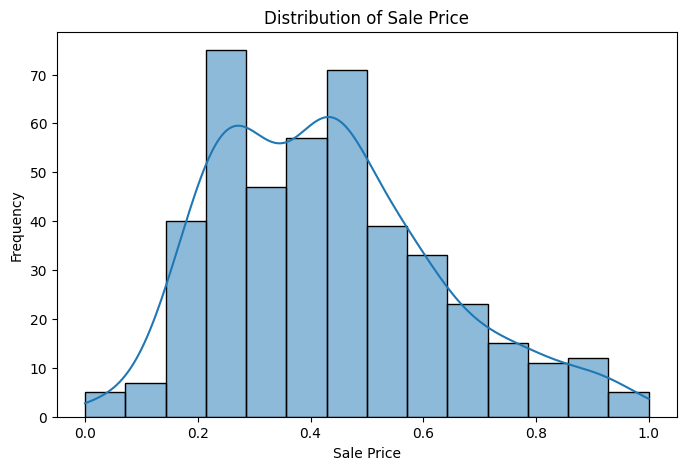

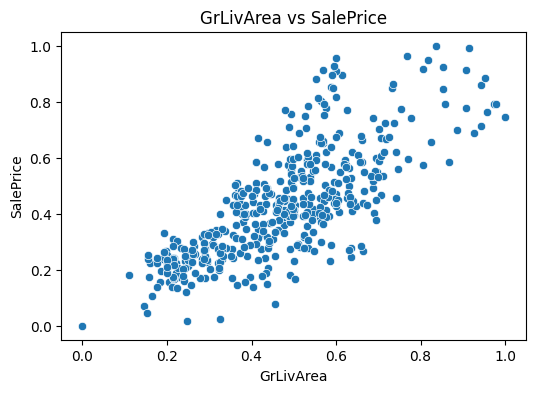

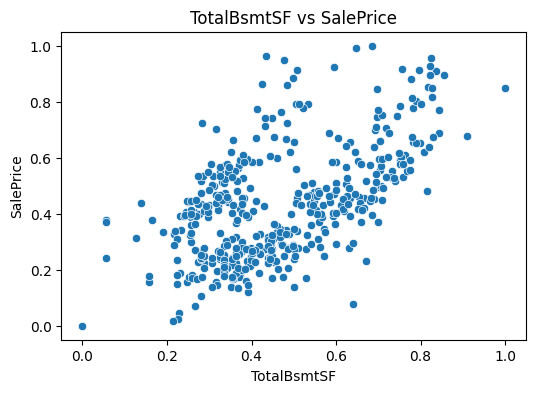

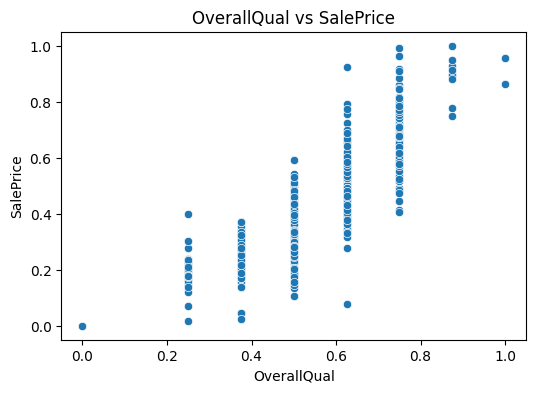

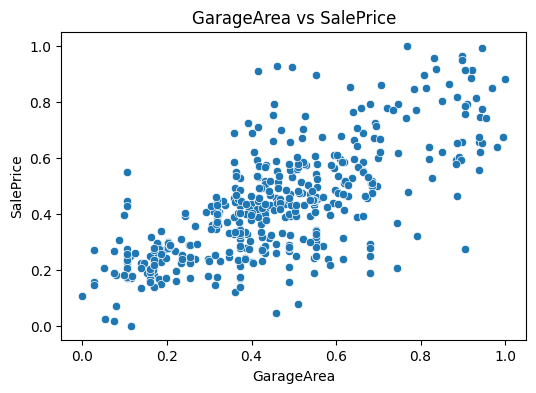

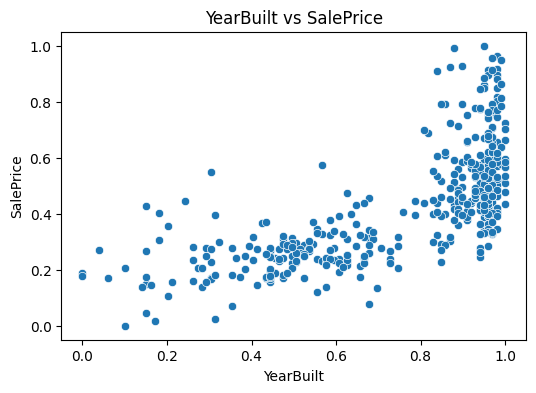

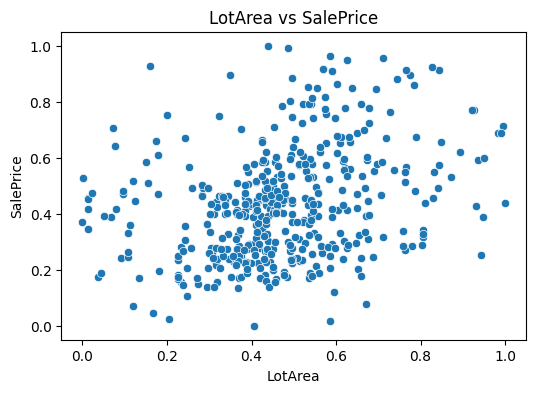

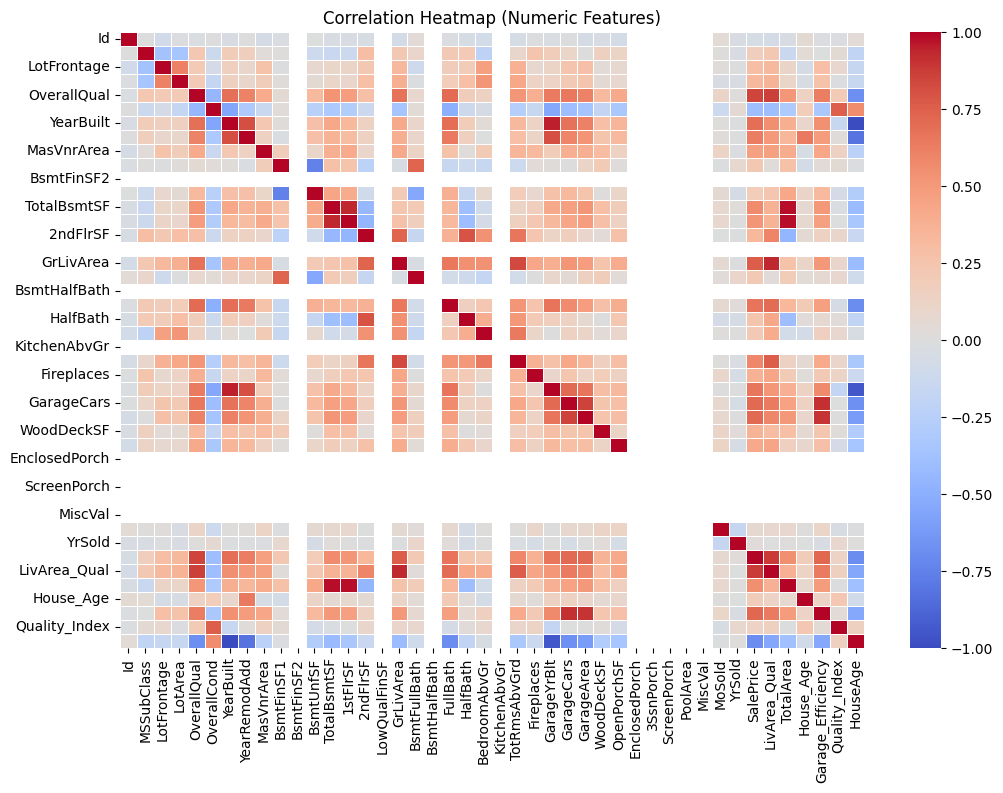


===== DATASET INSIGHTS =====

SalePrice Summary:
count    440.000000
mean       0.430236
std        0.198646
min        0.000000
25%        0.272414
50%        0.413621
75%        0.550431
max        1.000000
Name: SalePrice, dtype: float64

Top Correlations with SalePrice:
SalePrice            1.000000
LivArea_Qual         0.879580
OverallQual          0.844672
GrLivArea            0.760636
Garage_Efficiency    0.726454
GarageCars           0.717953
GarageArea           0.712075
YearBuilt            0.688723
FullBath             0.664611
GarageYrBlt          0.660210
Name: SalePrice, dtype: float64


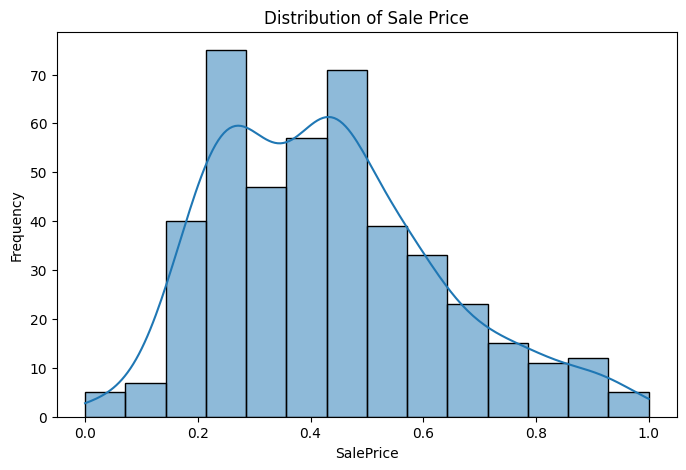

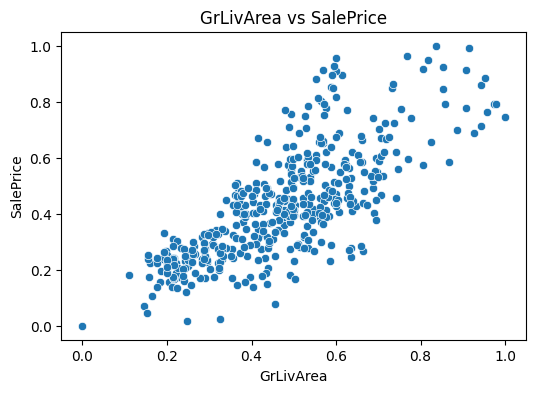

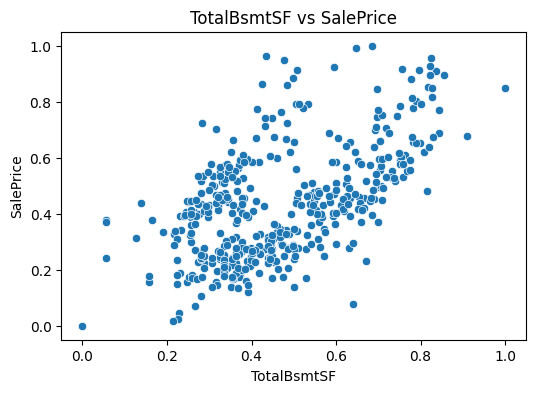

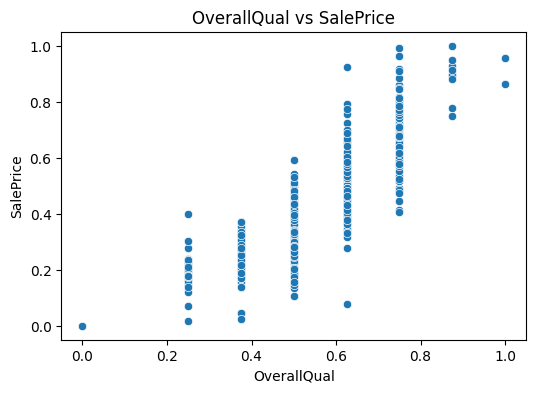

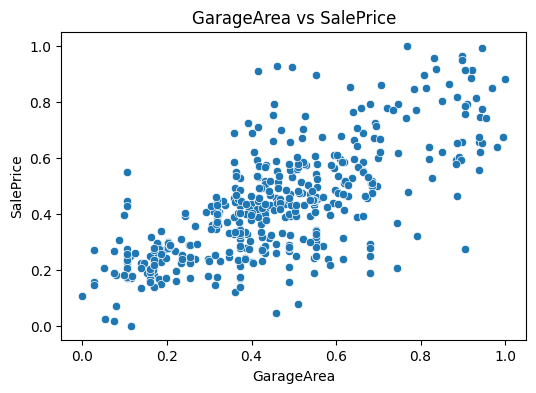

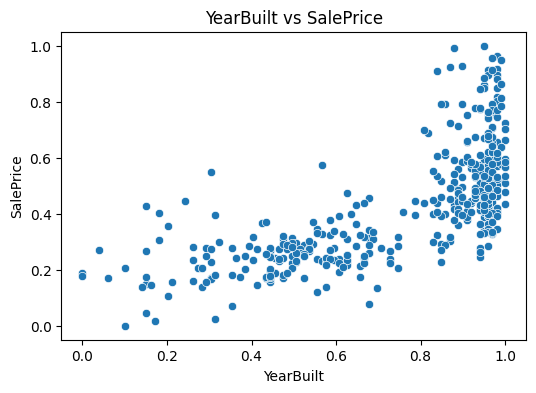

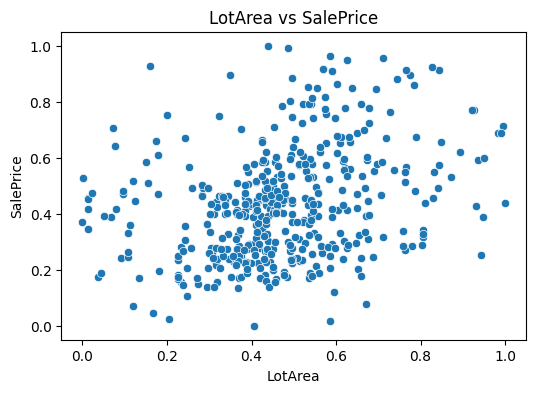

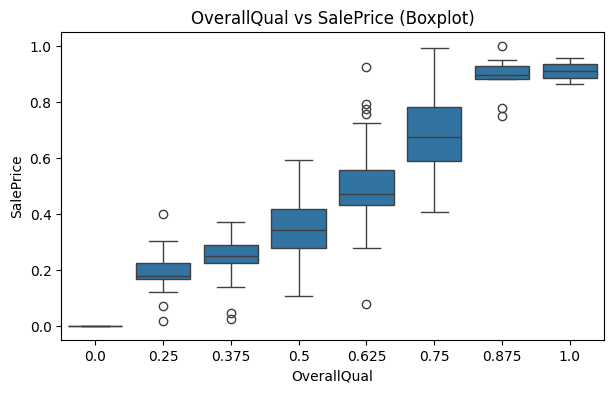

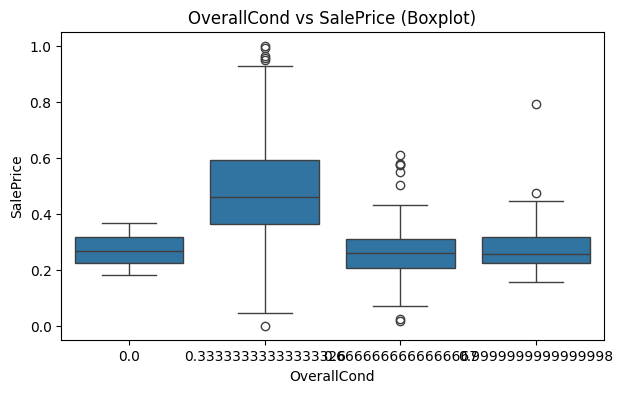

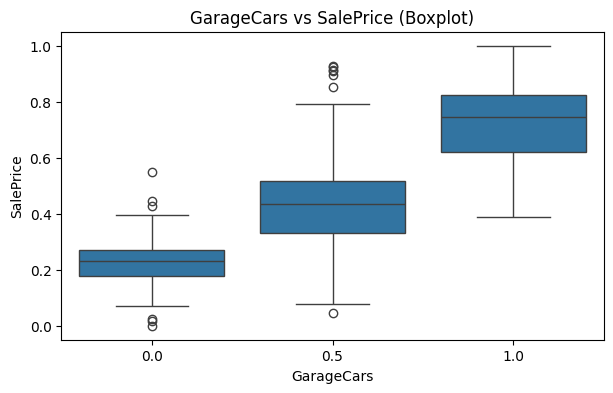

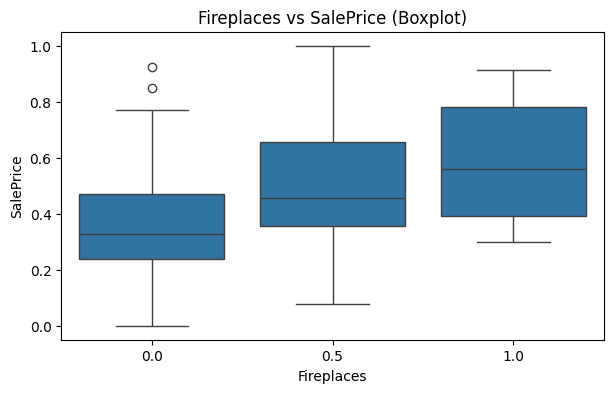

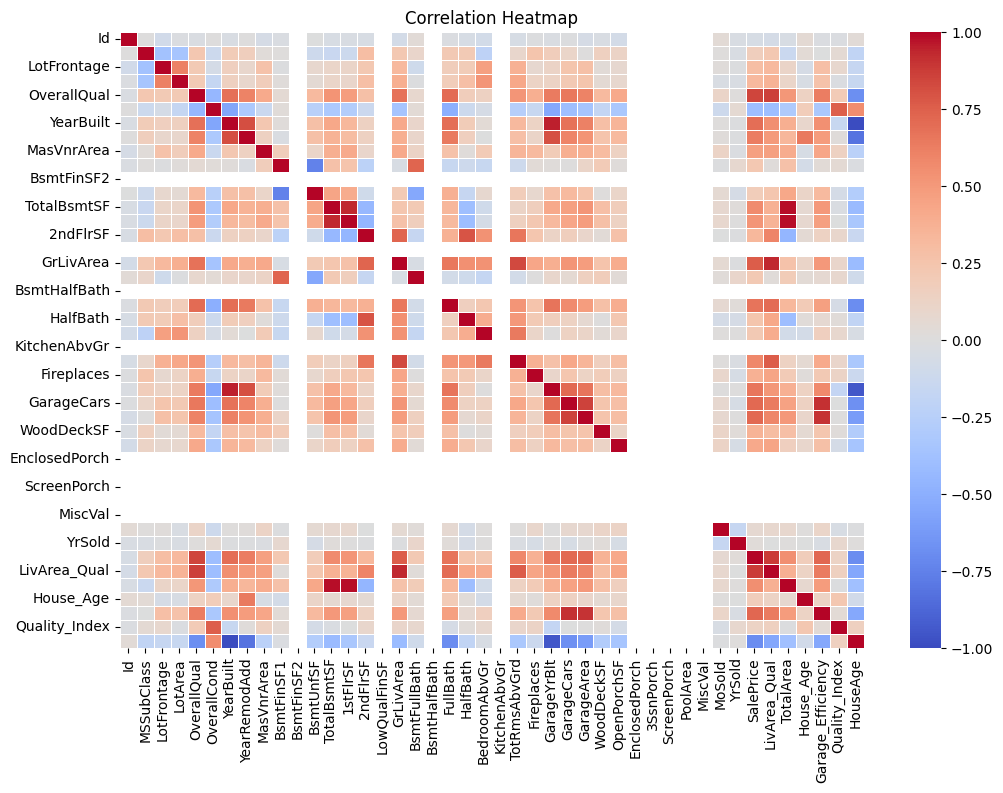

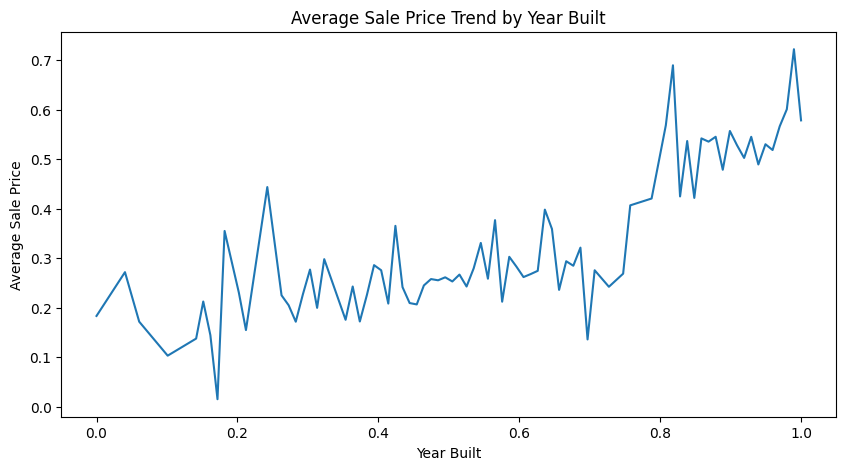


Data split completed successfully.
X_train shape: (352, 277)
X_test shape: (88, 277)

XGBoost model built successfully.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001061 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1880
[LightGBM] [Info] Number of data points in the train set: 352, number of used features: 102
[LightGBM] [Info] Start training from score 0.431369
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

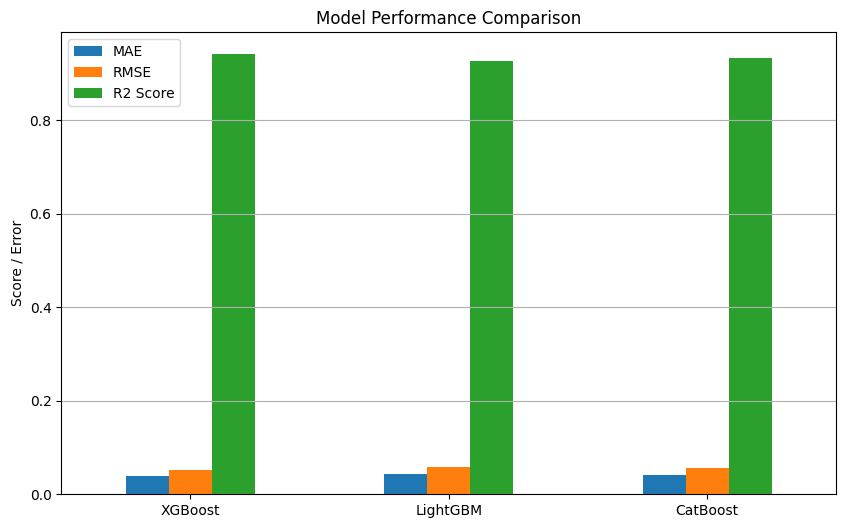

Saved at: c:\IITMPracticeFolder\Week9_Graded_Mini_Project_Aruna_Gosukonda\data\cleaned_house_prices.csv

===== BEST MODEL SUMMARY =====
Model: XGBoost
MAE         0.038917
RMSE        0.052174
R2 Score    0.940348
Name: XGBoost, dtype: float64

===== TOP FACTORS INFLUENCING SALE PRICE =====

LivArea_Qual         0.879580
OverallQual          0.844672
GrLivArea            0.760636
Garage_Efficiency    0.726454
GarageCars           0.717953
GarageArea           0.712075
YearBuilt            0.688723
FullBath             0.664611
GarageYrBlt          0.660210
YearRemodAdd         0.627344
Name: SalePrice, dtype: float64

===== DYNAMIC DECISION INSIGHTS =====

- Liv Area Qual has a very strong positive relationship with sale price (correlation: 0.88).
  Decision: Homes with better liv area qual are likely to have higher market value.

- Overall Qual has a very strong positive relationship with sale price (correlation: 0.84).
  Decision: Homes with better overall qual are likely to have hig

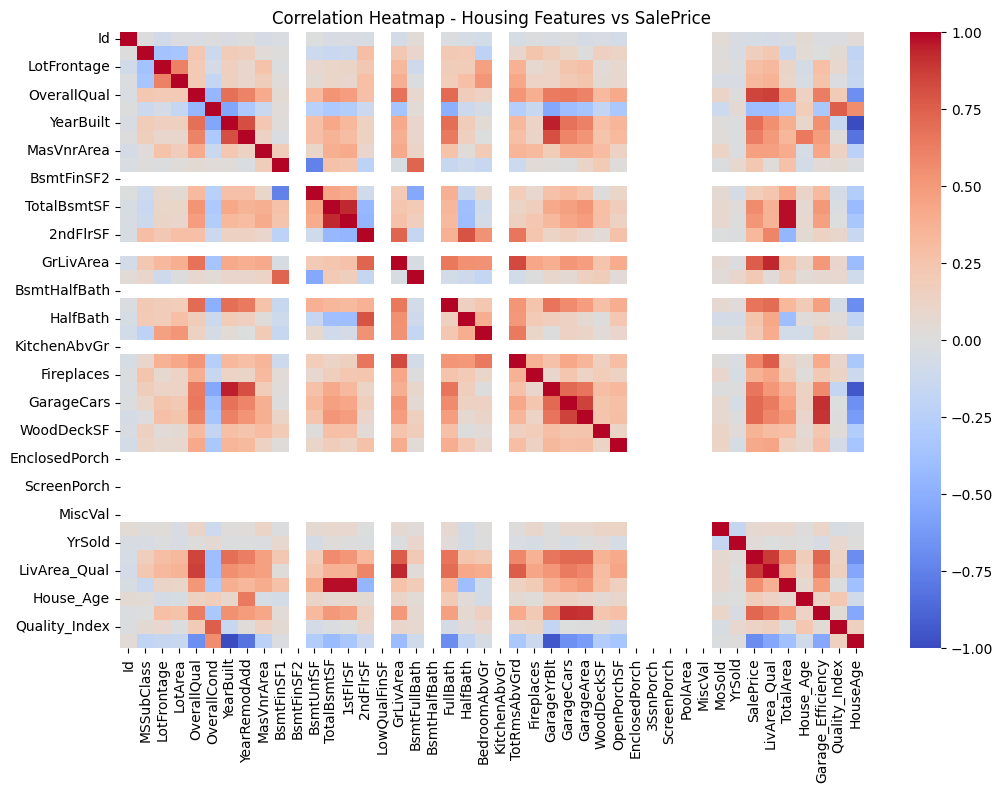


===== FINAL HOUSING DECISION RECOMMENDATION =====

Users should prioritize properties with:

- Strong liv area qual (impact score: 0.88)
- Strong overall qual (impact score: 0.84)
- Strong gr liv area (impact score: 0.76)
- Strong garage efficiency (impact score: 0.73)
- Strong garage cars (impact score: 0.72)

These factors show the strongest relationship with higher housing prices and resale potential.


In [11]:
def main():

    processor = DataProcessor("data/Week 9_Graded Mini Project_Dataset_houseprice.csv")

    processor.load_data()
    processor.handle_missing_values()
    processor.clean_data()
    processor.encode_categorical()
    processor.remove_outliers()
    processor.normalize_data()    
    
    df = processor.df

    fe = FeatureEngineer(df)

    df = fe.create_interaction_features()
    df = fe.bin_features()

    final_df = fe.get_data()

    print(final_df.head())

    eda = EDAAnalyzer(final_df)

    eda.plot_saleprice_distribution()
    eda.plot_feature_relationships()
    eda.plot_correlation_heatmap()
    eda.summary_insights()

    viz = DataVisualizer(final_df)

    viz.plot_saleprice_distribution()
    viz.plot_feature_vs_price()
    viz.plot_categorical_trends()
    viz.plot_correlation_heatmap()
    viz.plot_trend_analysis()

    builder = HousePriceModelBuilder(final_df, target_column="SalePrice")

    builder.prepare_data()

    builder.build_xgboost()
    builder.build_lightgbm()
    builder.build_catboost()

    builder.get_models()

    evaluator = ModelEvaluator(
    builder.get_models(),
    builder.X_test,
    builder.y_test
)

    results = evaluator.evaluate()

    # Show comparison table
    evaluator.show_results()

    # Get best model
    best_name, best_model = evaluator.get_best_model()

    print("\n🏆 Best Model:", best_model)

    saver = ModelSaver(best_model)
    saver.save_model("house_price_best_model.pkl")

    loaded_model = ModelSaver.load_model("house_price_best_model.pkl")
    print("Best Model Loaded from Pickle:")
    print(loaded_model)

    report = ReportGenerator(results, df=final_df)

    report.final_report()
    report.plot_model_comparison()
    report.save_cleaned_data()
    report.best_model_summary()

    analyzer = HousingDecisionAnalyzer(final_df)

    # Analyze important factors
    analyzer.analyze_price_factors()

    # Visualize correlations
    analyzer.plot_price_correlation()

    # Final recommendations
    analyzer.final_recommendation()


if __name__ == "__main__":
    main()